In [2]:
#############################################################
# Local CBFI Experiment with Wine Quality and Insurance Cost Datasets
# Compare with Other methods
# 2026-06-03    
#############################################################

import local_cbfi_clean_20260410 as CBFI 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
##############################################################################
# CLASSIFICATION
##############################################################################

In [ ]:

def load_and_preprocess_wine_data(random_seed=42):
    
    df = pd.read_csv("dataset/winequality-red.csv") 
    df.drop_duplicates(inplace=True)     # 중복제거
    
    X = df.drop('quality', axis=1)
    y = df['quality']

    # split dataset into train/test sets (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed, stratify=y
    )
    
    # 4. data scaling (StandardScaler)
    # need for internal KNN operation in CBFI's _get_conditional_samples() 
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
    
    # reset index
    X_train_scaled.reset_index(drop=True, inplace=True)
    X_test_scaled.reset_index(drop=True, inplace=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


X_train, X_test, y_train, y_test, scaler = load_and_preprocess_wine_data()
print(f"Dataset Loaded: {len(X_train)} train samples, {len(X_test)} test samples")

# RF model build
model_wine = RandomForestClassifier(n_estimators=50,  random_state=42)
model_wine.fit(X_train, y_train)
# model_wine.score(X_test, y_test)
print(f"Random Forest Test Accuracy: {model_wine.score(X_test, y_test):.4f}")

Dataset Loaded: 1087 train samples, 272 test samples
Random Forest Test Accuracy: 0.6250


In [ ]:
#############
## CBFI #####
#############

Sample Index: 8, Actual Quality: 7, Predicted Quality: 7
Calculating Local CBFI for all features...
                      Power (G1)  Others (G2)  Common (G3)  Interact (G4)  \
Feature                                                                     
residual sugar              0.00         0.95         0.05           0.00   
citric acid                 0.00         0.92         0.08           0.00   
free sulfur dioxide         0.00         0.85         0.15           0.00   
chlorides                   0.00         0.89         0.11           0.00   
density                     0.00         0.67         0.33           0.00   
pH                          0.00         0.77         0.23           0.00   
volatile acidity            0.08         0.46         0.38           0.08   
fixed acidity               0.05         0.68         0.14           0.13   
total sulfur dioxide        0.00         0.65         0.14           0.21   
sulphates                   0.23         0.35        

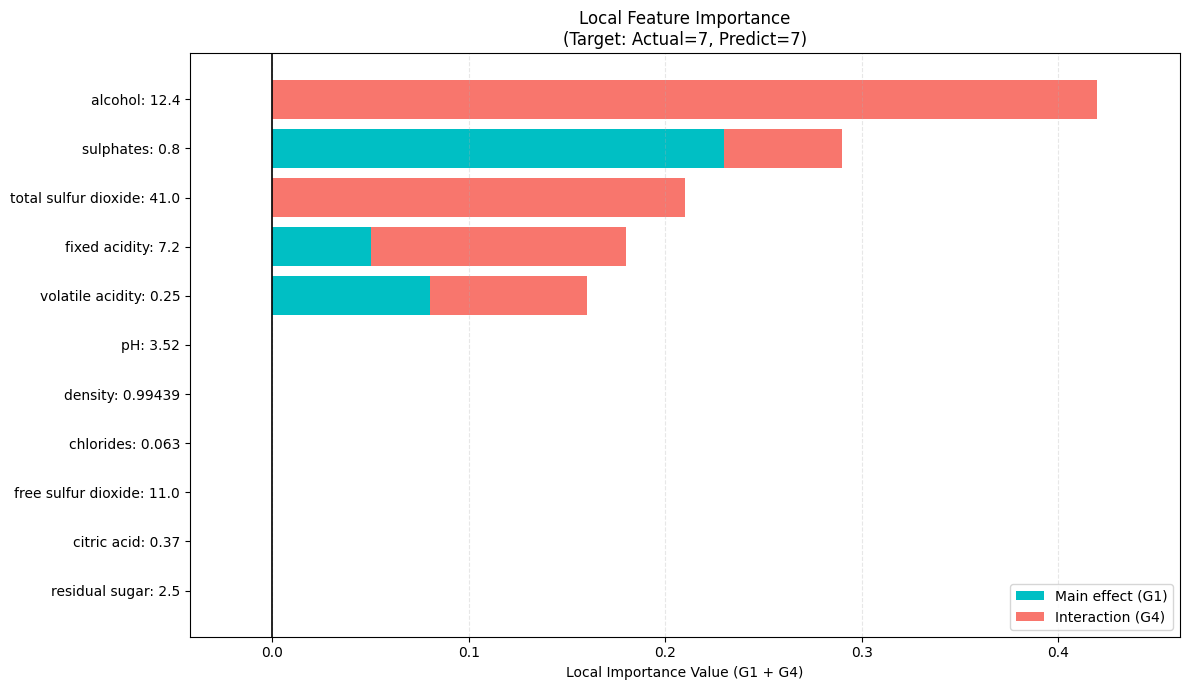

Analyzing 1:1 interactions for feature:alcohol


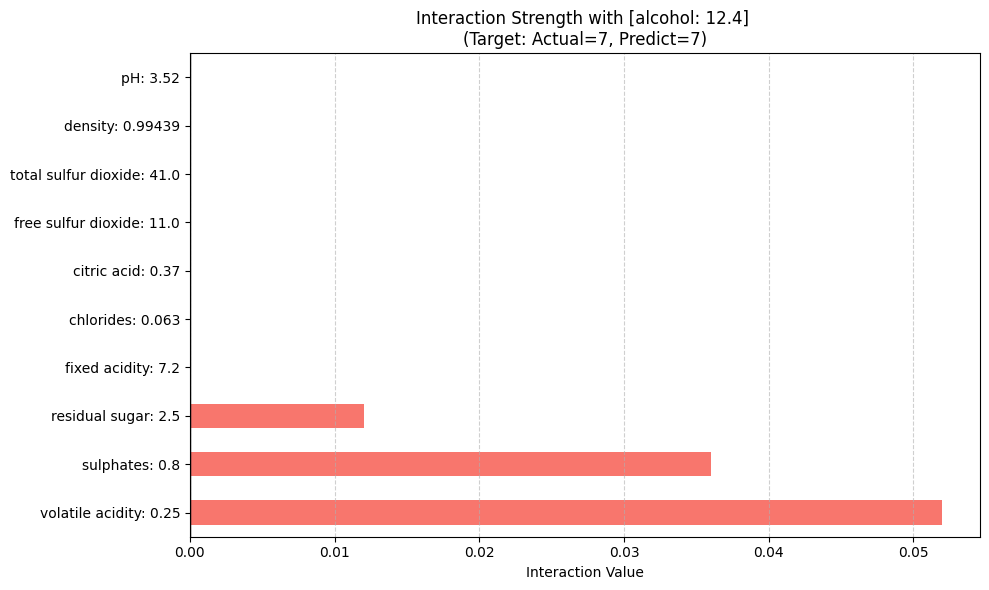

Analyzing 1:1 interactions for feature:free sulfur dioxide


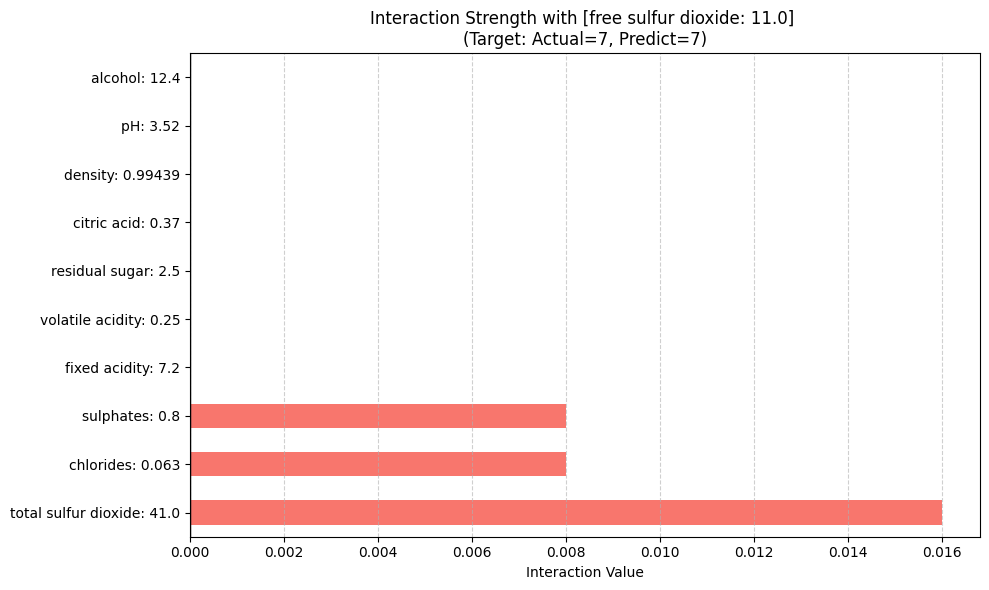

In [ ]:
pick = 8  # pick a sample from test set (index-based)
sample_instance = X_test.iloc[pick]   
actual_1 = y_test[pick]
predicted_1 = model_wine.predict(pd.DataFrame([sample_instance]))[0]
print(f"Sample Index: {pick}, Actual Quality: {actual_1}, Predicted Quality: {predicted_1}")

df_cbfi_table_1 = CBFI.get_cbfi_table(model_wine, sample_instance, X_train, n_samples=100, job_type='classification')
print(df_cbfi_table_1)
CBFI.visualize_feature_contribution(df_cbfi_table_1, sample_instance, actual_1, predicted_1, scaler)

print(f"Analyzing 1:1 interactions for feature:{X_train.columns[10]}") # alcohol
df_interact_1 = CBFI.get_local_pairwise_interaction(model_wine, sample_instance, X_train, X_train.columns[10], n_samples=100, 
                                             job_type='classification')
CBFI.visualize_local_pairwise_interaction(df_interact_1, sample_instance, actual_1, predicted_1, scaler)

print(f"Analyzing 1:1 interactions for feature:{X_train.columns[5]}") # free sulfur dioxide
df_interact_12 = CBFI.get_local_pairwise_interaction(model_wine, sample_instance, X_train, X_train.columns[5], n_samples=100, 
                                             job_type='classification')
CBFI.visualize_local_pairwise_interaction(df_interact_12, sample_instance, actual_1, predicted_1, scaler)


Total 55 pairs to analyze...
Analyzing interaction : fixed acidity - volatile acidity...
Analyzing interaction : fixed acidity - citric acid...
Analyzing interaction : fixed acidity - residual sugar...
Analyzing interaction : fixed acidity - chlorides...
Analyzing interaction : fixed acidity - free sulfur dioxide...
Analyzing interaction : fixed acidity - total sulfur dioxide...
Analyzing interaction : fixed acidity - density...
Analyzing interaction : fixed acidity - pH...
Analyzing interaction : fixed acidity - sulphates...
Analyzing interaction : fixed acidity - alcohol...
Analyzing interaction : volatile acidity - citric acid...
Analyzing interaction : volatile acidity - residual sugar...
Analyzing interaction : volatile acidity - chlorides...
Analyzing interaction : volatile acidity - free sulfur dioxide...
Analyzing interaction : volatile acidity - total sulfur dioxide...
Analyzing interaction : volatile acidity - density...
Analyzing interaction : volatile acidity - pH...
Analyz

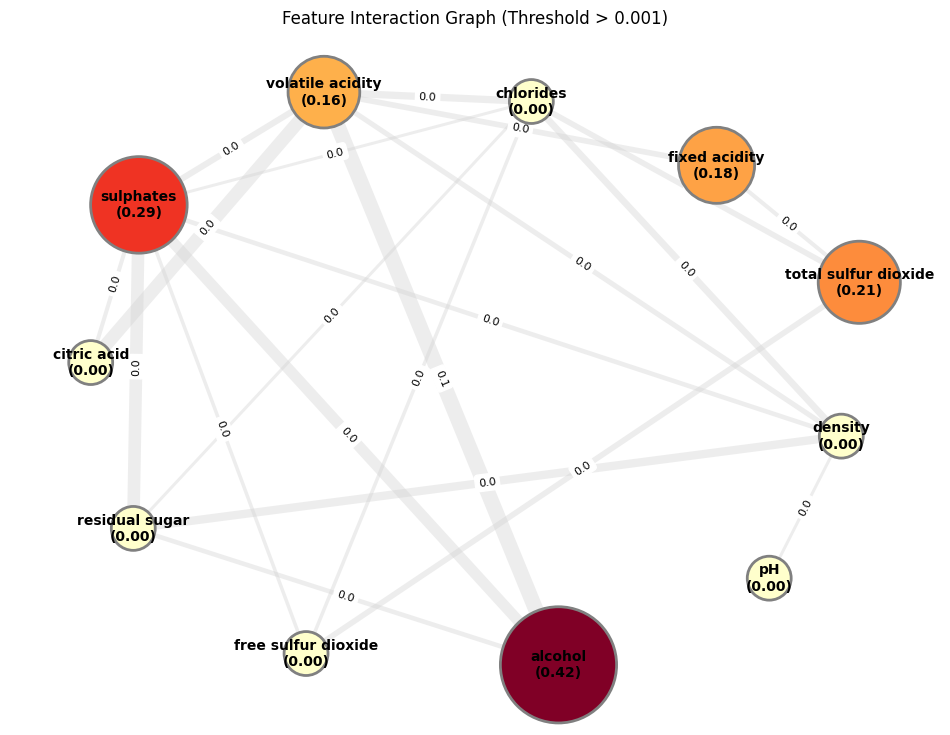

In [8]:
## interaction network graph (takes long time)
importance_df_1 = df_cbfi_table_1['Total']
interaction_df_1 = CBFI.generate_all_interactions(model_wine, sample_instance, X_train, n_samples=100, job_type='classification')

CBFI.visualize_draggable_interaction_graph(importance_df_1, interaction_df_1, threshold=0.001) # interactive


In [ ]:
#############
## SHAP #####
#############

c:\Users\DKU\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP Analysis for Predicted Class: 7


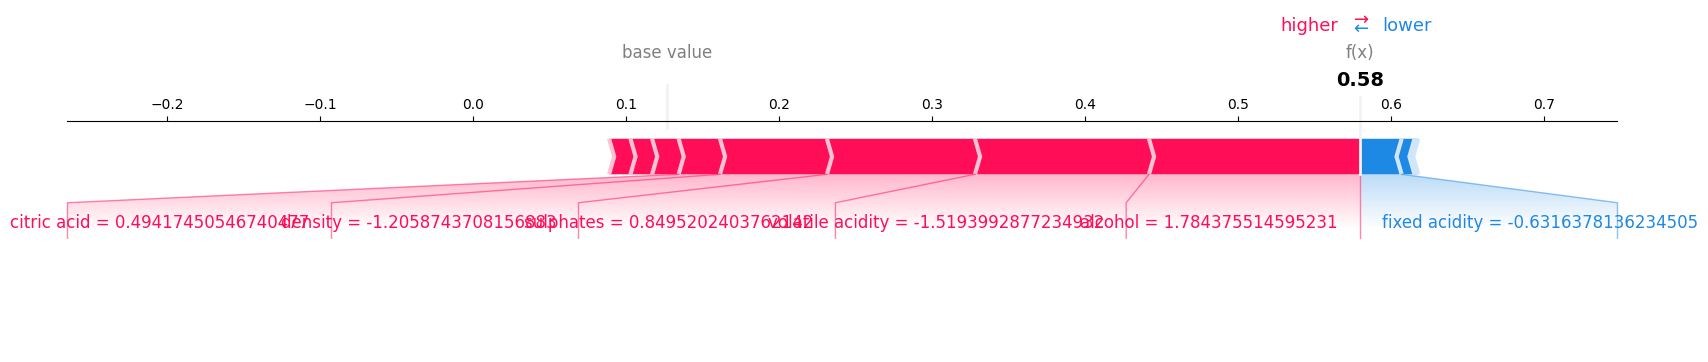

In [9]:
import shap

# 1. initialize SHAP Explainer (tree model specific)
explainer_shap = shap.TreeExplainer(model_wine)

# 2. calculate SHAP values for the test instance
# Since it's a multi-class problem, shap_values is a list of arrays with shape [n_classes, n_samples, n_features]
shap_values = explainer_shap.shap_values(sample_instance)

# 3. Visualize the results for the predicted class
# Find the index of the predicted class (e.g., if prediction is 6, find its index in the class list)
pred_class_idx = list(model_wine.classes_).index(predicted_1)

print(f"SHAP Analysis for Predicted Class: {predicted_1}")
shap.initjs() # for jupyter notebook environment
shap.force_plot(
    explainer_shap.expected_value[pred_class_idx], 
    shap_values[:,pred_class_idx],          # feature importance for the predicted class
    sample_instance,
    matplotlib=True
)

In [10]:
# SHAP feature importance
SHAP_imp = pd.Series(shap_values[:, pred_class_idx], index=X_train.columns)
CBFI_imp = df_cbfi_table_1['Total']
CBFI_imp = CBFI_imp.reindex(sample_instance.index)  # sort by SHAP feature order
print(SHAP_imp.corr(CBFI_imp))
print(CBFI_imp.corr(np.abs(SHAP_imp)))


0.6253668250864839
0.7261378264801192


In [11]:
# feature interaction
interaction_values = explainer_shap.shap_interaction_values(X_test.iloc[pick:pick+1])

# shape of result: (# of samples, feature count, feature count)
# 18th sample's 11x11 interaction matrix
sample_interaction = interaction_values[0][10,:,pred_class_idx]
print(sample_interaction)

[-0.00379455 -0.00830158  0.00820674  0.0099594   0.00272189 -0.00649763
  0.00678404 -0.01100824 -0.00170217  0.0144896   0.12725414]


In [ ]:
###########
## LIME
############

In [ ]:
from lime import lime_tabular

# 1. initialize LIME Explainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=model_wine.classes_.astype(str).tolist(),
    mode='classification'
)

# 2. generate explanation for the test instance
# num_features determines how many top features to display

class_idx = list(model_wine.classes_).index(predicted_1)
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[pick].values, 
    predict_fn=model_wine.predict_proba,
    num_features=X_test.shape[1],  # display all features
    labels=[class_idx] # request explanation for the predicted class
)

# 3. show the results
for element in exp.as_list(label=class_idx):
    print(element )


('alcohol > 0.69', 0.11339167627377898)
('sulphates > 0.38', 0.07593338883697992)
('volatile acidity <= -0.77', 0.06898460439485188)
('density <= -0.59', 0.0403472883805044)
('chlorides <= -0.36', 0.0147034602103762)
('-0.07 < citric acid <= 0.80', 0.007607537872999783)
('-0.25 < residual sugar <= 0.05', -0.0061842229215158685)
('-0.27 < total sulfur dioxide <= 0.49', -0.004607110637756179)
('-0.69 < fixed acidity <= -0.24', -0.0023765553697882623)
('pH > 0.58', -0.0011717448224961553)
('-0.85 < free sulfur dioxide <= -0.19', -0.00036291029275932116)


In [17]:
local_exp = exp.local_exp[class_idx]

LIME_imp = pd.Series({
    explainer_lime.feature_names[idx]: val for idx, val in local_exp
}, name='importance')

LIME_imp = LIME_imp.reindex(sample_instance.index)

print(CBFI_imp.corr(np.abs(LIME_imp)))
print(LIME_imp.corr(SHAP_imp))


0.7597463712053464
0.9571312394458872


In [ ]:
#######################################
# Fidelity Test
#######################################

In [ ]:
import matplotlib.pyplot as plt

def perform_fidelity_test(model, instance, importance_dict, background_data, n_steps=5):
    """
    Prediction Probability Drop (Fidelity) Measurement
    """
    import pandas as pd
    import numpy as np

    feature_names = instance.index
    instance_df = pd.DataFrame([instance])
    
    # 1. check the model's predicted label
    target_label = model.predict(instance_df)[0]
    
    # 2. convert the label value (e.g., 7) to the index of the probability array (e.g., 4) 
    target_idx = list(model.classes_).index(target_label)
    
    # 3. extract the initial probability value
    initial_proba = model.predict_proba(instance_df)[0][target_idx]
    
    reference_values = background_data.median()
    results = {}
    
    for method_name, importance_values in importance_dict.items():
        # sort features by importance
        sorted_features = pd.Series(importance_values, index=feature_names).abs().sort_values(ascending=False).index
        
        probas = [initial_proba]
        temp_instance = instance.copy()
        
        # remove the top n_steps features sequentially
        for i in range(min(n_steps, len(sorted_features))):
            feat_to_remove = sorted_features[i]
            temp_instance[feat_to_remove] = reference_values[feat_to_remove]
            
            # extract probability using the updated index (target_idx)
            new_proba = model.predict_proba(pd.DataFrame([temp_instance]))[0][target_idx]
            probas.append(new_proba)
            
        results[method_name] = probas
        
    return results


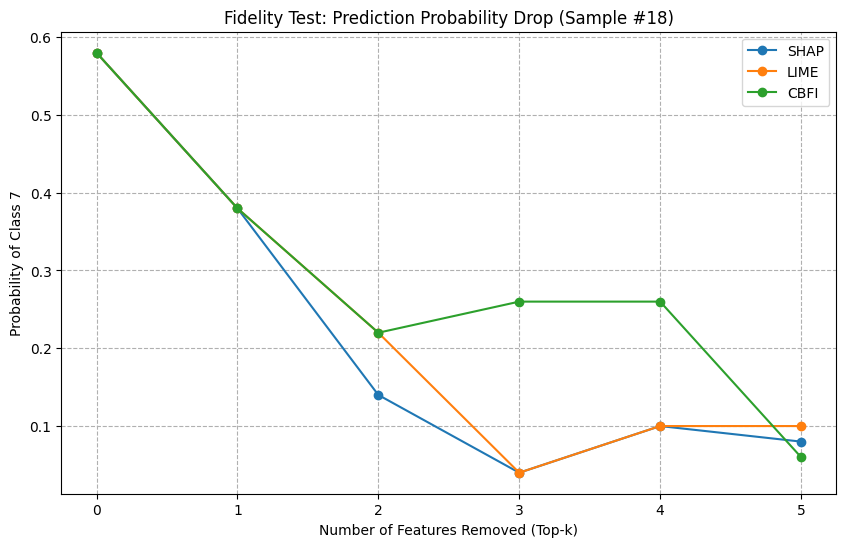

In [19]:
# 1. prepare importance data
importance_dict = {
    'SHAP': SHAP_imp, 
    'LIME': LIME_imp, 
    'CBFI': CBFI_imp  # G1 + G4 
}

# 2. execute the test
fidelity_results = perform_fidelity_test(model_wine, X_test.iloc[pick], importance_dict, X_train)

# 3. visualization
plt.figure(figsize=(10, 6))
for method, scores in fidelity_results.items():
    plt.plot(range(len(scores)), scores, marker='o', label=method)

plt.title("Fidelity Test: Prediction Probability Drop (Sample #18)")
plt.xlabel("Number of Features Removed (Top-k)")
plt.ylabel(f"Probability of Class 7")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()


In [ ]:
##########################################
# Synergy Removal Test
##########################################

In [20]:
def perform_synergy_test(model, instance, cbfi_df, shap_df, background_data):
    """
    Measuring the Synergistic Effect of Simultaneously Removing Interacting Variable Pairs
    """
    feature_names = instance.index
    target_label = model.predict(pd.DataFrame([instance]))[0]
    target_idx = list(model.classes_).index(target_label)
    initial_proba = model.predict_proba(pd.DataFrame([instance]))[0][target_idx]
    
    # Replacement Value Assignment (Median)
    ref_vals = background_data.median()
    
    # 1. Selection of Variable Pairs for Testing
    # CBFI: Top-2 Variables Ranked by G4 (Interaction)
    top_g4_pair = cbfi_df['Interact (G4)'].sort_values(ascending=False).index[:2].tolist()
    
    # SHAP: Top-2 Variables by Absolute Contribution
    top_shap_pair = shap_df.abs().sort_values(ascending=False).index[:2].tolist()
    
    pairs = {'CBFI (G4 Pair)': top_g4_pair, 'SHAP (Top Pair)': top_shap_pair}
    results = []

    for label, pair in pairs.items():
        fx, fy = pair[0], pair[1]
        
        # Scenario-based Sample Generation
        inst_x = instance.copy(); inst_x[fx] = ref_vals[fx] # Remove Fx
        inst_y = instance.copy(); inst_y[fy] = ref_vals[fy] # Remove Fy
        inst_xy = instance.copy(); inst_xy[fx] = ref_vals[fx]; inst_xy[fy] = ref_vals[fy] # Remove Both
        
        # Probability Measurement
        p_x = model.predict_proba(pd.DataFrame([inst_x]))[0][target_idx]
        p_y = model.predict_proba(pd.DataFrame([inst_y]))[0][target_idx]
        p_xy = model.predict_proba(pd.DataFrame([inst_xy]))[0][target_idx]
        
        # Drop Calculation
        drop_x = initial_proba - p_x
        drop_y = initial_proba - p_y
        drop_joint = initial_proba - p_xy
        
        results.append({
            'Method': label,
            'Pair': f"{fx} & {fy}",
            'Individual_Sum': drop_x + drop_y,
            'Joint_Drop': drop_joint,
            'Synergy_Index': drop_joint / (drop_x + drop_y + 1e-9)
        })

    return pd.DataFrame(results)



In [21]:
# Execute the synergy test
synergy_results = perform_synergy_test(model_wine, X_test.iloc[pick], df_cbfi_table_1, SHAP_imp, X_train)
print(synergy_results)

            Method                            Pair  Individual_Sum  \
0   CBFI (G4 Pair)  alcohol & total sulfur dioxide            0.18   
1  SHAP (Top Pair)      alcohol & volatile acidity            0.38   

   Joint_Drop  Synergy_Index  
0        0.14       0.777778  
1        0.44       1.157895  


In [ ]:
##########################################
# Test effect of a feature removal
# Drop(alcohol), Drop(total sulfur dioxide)
##########################################

In [23]:
def check_individual_drops(model, instance, background_data):
    """
   "Measure the Probability Drop from Individual Feature Removal
    """
    feature_names = instance.index
    target_label = model.predict(pd.DataFrame([instance]))[0]
    target_idx = list(model.classes_).index(target_label)
    initial_proba = model.predict_proba(pd.DataFrame([instance]))[0][target_idx]

    # Baseline Replacement Value (Training Data Median)
    ref_vals = background_data.median()

    features_to_check = ['alcohol', 'total sulfur dioxide']
    results = {}

    for feat in features_to_check:
        temp_instance = instance.copy()
        temp_instance[feat] = ref_vals[feat]
        
        # Prediction after Feature Removal
        new_proba = model.predict_proba(pd.DataFrame([temp_instance]))[0][target_idx]
        drop_val = initial_proba - new_proba
        
        results[feat] = {
            'Original_Proba': initial_proba,
            'New_Proba': new_proba,
            'Drop': drop_val
        }

    return pd.DataFrame(results).T

# execute the individual drop check
individual_drops = check_individual_drops(model_wine, X_test.iloc[pick], X_train)
print(individual_drops)


                      Original_Proba  New_Proba  Drop
alcohol                         0.58       0.38  0.20
total sulfur dioxide            0.58       0.60 -0.02


In [ ]:
#################################################################
# Partial Dependence–Style Probability Curves for Alcohol Levels with and without Sulfates
#################################################################

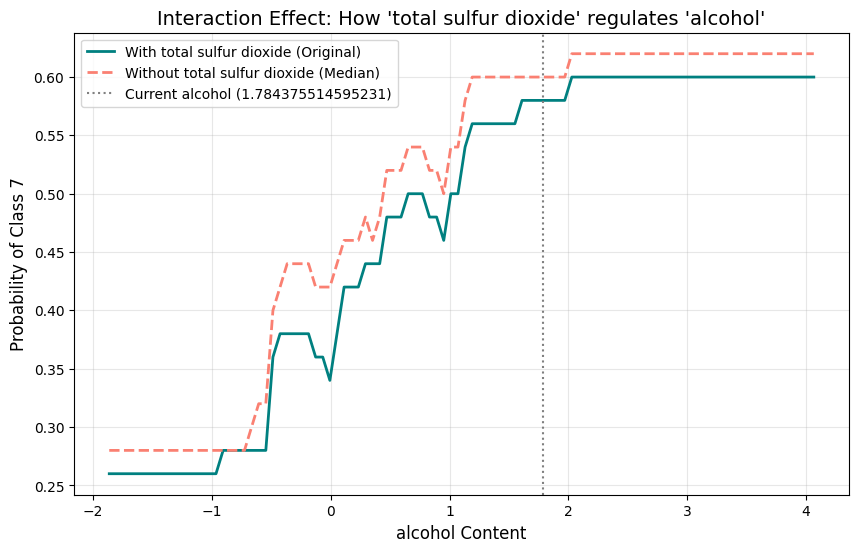

In [ ]:
def plot_interaction_sensitivity(model, instance, background_data, target_feat='alcohol', interact_feat='total sulfur dioxide'):
    """
    Visualization of the Moderating Effect of SO₂ on Alcohol–Prediction Relationships
    """
    # 1. Preparation
    target_label = model.predict(pd.DataFrame([instance]))[0]
    target_idx = list(model.classes_).index(target_label)
    ref_val = background_data[interact_feat].median()
    
    # 2. Set the Alcohol Range (Minimum to Maximum Values in the Dataset)
    x_range = np.linspace(background_data[target_feat].min(), background_data[target_feat].max(), 100)
    
    proba_with_so2 = []
    proba_without_so2 = []
    
    for val in x_range:
        # Scenario A: Preserve the Original SO₂ State
        inst_a = instance.copy()
        inst_a[target_feat] = val
        p_a = model.predict_proba(pd.DataFrame([inst_a]))[0][target_idx]
        proba_with_so2.append(p_a)
        
        # Scenario B: SO₂ Removed (Replaced with the Median Value)
        inst_b = instance.copy()
        inst_b[target_feat] = val
        inst_b[interact_feat] = ref_val
        p_b = model.predict_proba(pd.DataFrame([inst_b]))[0][target_idx]
        proba_without_so2.append(p_b)
        
    # 3. visualization
    plt.figure(figsize=(10, 6))
    plt.plot(x_range, proba_with_so2, label=f'With {interact_feat} (Original)', color='teal', linewidth=2)
    plt.plot(x_range, proba_without_so2, label=f'Without {interact_feat} (Median)', color='salmon', linestyle='--', linewidth=2)
    
    # Mark the Current Instance's Alcohol Value
    plt.axvline(x=instance[target_feat], color='gray', linestyle=':', label=f'Current {target_feat} ({instance[target_feat]})')
    
    plt.title(f"Interaction Effect: How '{interact_feat}' regulates '{target_feat}'", fontsize=14)
    plt.xlabel(f"{target_feat} Content", fontsize=12)
    plt.ylabel(f"Probability of Class {target_label}", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# execute the test
plot_interaction_sensitivity(model_wine, X_test.iloc[pick], X_train)



In [ ]:
##############################################################################
# CLASSIFICATION
##############################################################################

In [ ]:
# omitted for brevity 